# 텍스트 마이닝

In [38]:
import konlpy
import re
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

moon = open('moon2.txt',encoding='UTF-8').read() # 분석할 파일 열기
moon = re.sub('[^가-힣]',' ',moon) # 한글제외한 문자 ' '치환

hannanum = konlpy.tag.Hannanum() #문장에서 명사를 추출
nous = hannanum.nouns(moon) # 문장에서 명사만 뽑아 리스트로 반환

In [39]:
# 명사 리스트를 판다스 데이터프레임으로 변환
df_word = pd.DataFrame({'word' : nous})

# 단어 글자수를 뽑아본다
df_word['count'] = df_word['word'].str.len()
df_word = df_word.query('count >= 2')
df_word.sort_values('count')

,word,count
47,나라,2
48,희생,2
49,헌신,2
50,감내,2
51,우리,2
...,...,...
326,더불어민주당,6
215,무소불위의권력,7
282,대화를정례화하,7
17,첫걸음을내딛습니다,9


In [40]:
# 단어의 사용빈도를 구하고 정렬하라
df_word = df_word.groupby('word',as_index=False).agg(n=('word','count')).sort_values('n',ascending=False)
df_word

,word,n
56,대통령,26
33,국민,23
59,대한민국,11
145,여러분,9
153,우리,8
...,...,...
243,협상,1
244,혼란,1
245,후보들,1
246,훗날,1


<Axes: xlabel='n', ylabel='word'>

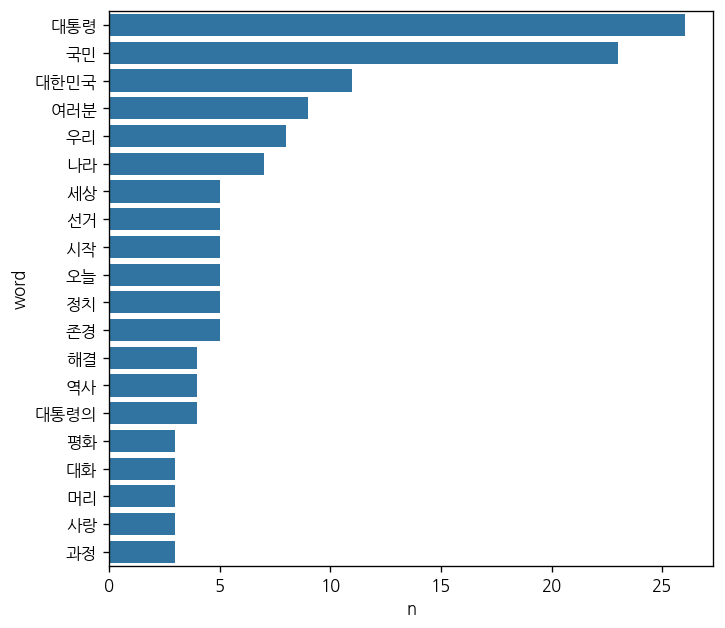

In [41]:
# 막대그래프를 그린다

plt.rcParams.update({'font.family': 'NanumGothic',
                    'figure.dpi' : '120',
                    'figure.figsize' : [6.5,6]})
top_20 = df_word.head(20)
sns.barplot(data=top_20, y='word', x='n')

<Axes: xlabel='n', ylabel='word'>

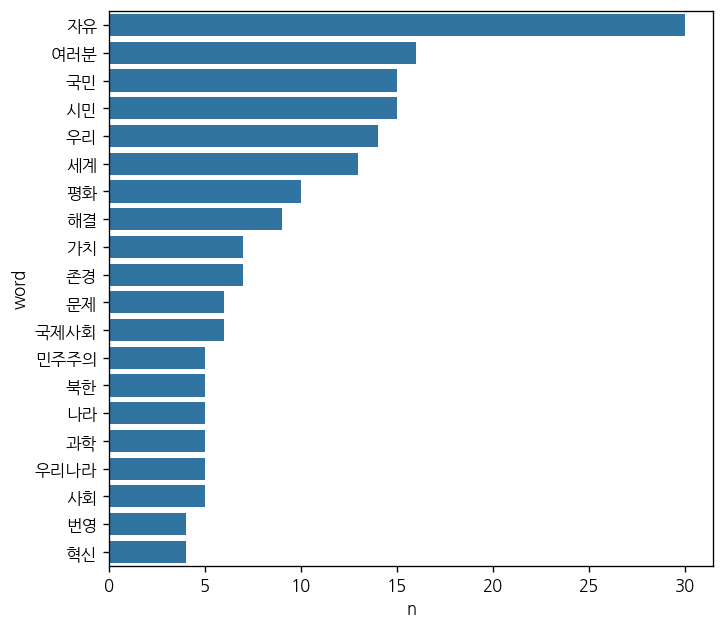

In [37]:
# 윤석열 취임연설문 분
yoon = open('yoon.txt',encoding='UTF-8').read()
yoon = re.sub('[^가-힣]',' ', yoon)

hannanum = konlpy.tag.Hannanum() #문장에서 명사를 추출
nous = hannanum.nouns(yoon) # 문장에서 명사만 뽑아 리스트로 반환

df_yoon = pd.DataFrame({'word': nous})
df_yoon['count'] = df_yoon['word'].str.len()
df_yoon = df_yoon.query('count >= 2')

yoons_paper = df_yoon.groupby('word',as_index=False).agg(n = ('word','count')).sort_values('n',ascending=False).head(20)
yoons_paper

sns.barplot(data=yoons_paper, x='n', y='word')

<Axes: xlabel='n', ylabel='word'>

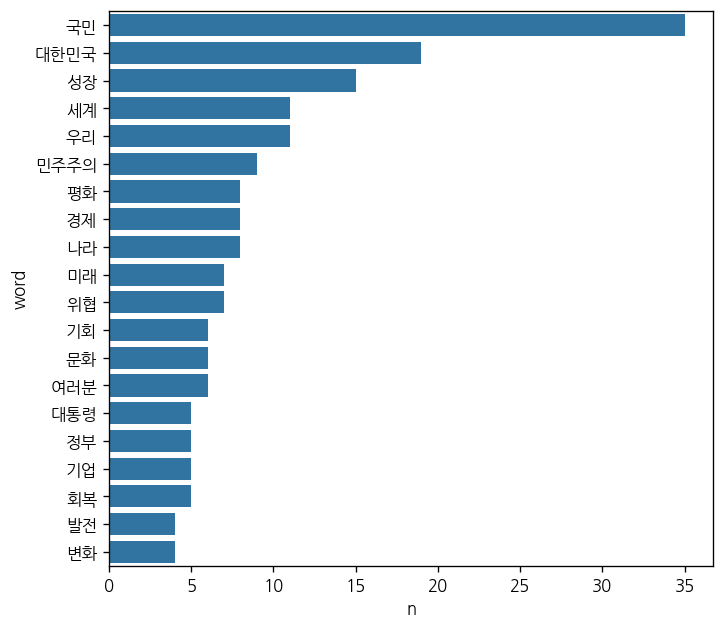

In [42]:
# 이재명 취임연설문
lee = open('lee.txt',encoding='UTF-8').read()
lee = re.sub('[^가-힣]',' ', lee)

hannanum = konlpy.tag.Hannanum() #문장에서 명사를 추출
nous = hannanum.nouns(lee) # 문장에서 명사만 뽑아 리스트로 반환

df_lee = pd.DataFrame({'word': nous})
df_lee['count'] = df_lee['word'].str.len()
df_lee = df_lee.query('count >= 2')

lees_paper = df_lee.groupby('word',as_index=False).agg(n = ('word','count')).sort_values('n',ascending=False).head(20)
lees_paper

sns.barplot(data=lees_paper, x='n', y='word')